# Quickshift Graph Visualization on CIFAR-10
This notebook demonstrates Quickshift's graph construction step by visualizing the directed graph G₀(P)
on a CIFAR-10 image of class 2 (bird). Nodes are pixels, arrows point to higher-density neighbors, and
local maxima (sinks) are highlighted in red.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tensorflow.keras.datasets import cifar10
from skimage.color import rgb2gray
from skimage import img_as_float
%matplotlib inline

In [10]:
def compute_density(img, kw, ks, sigma0=1e-5):
    H, W, _ = img.shape
    P = np.zeros((H, W))
    for i in range(H):
        for j in range(W):
            i0, i1 = max(0, i-kw), min(H, i+kw+1)
            j0, j1 = max(0, j-kw), min(W, j+kw+1)
            patch = img[i0:i1, j0:j1]
            di = np.arange(i0, i1)[:,None] - i
            dj = np.arange(j0, j1)[None,:] - j
            spatial_sq = di**2 + dj**2
            diff = patch - img[i,j]
            color_sq = np.sum(diff**2, axis=2)
            w = np.exp(-(spatial_sq + color_sq) / (2*ks*ks))
            P[i,j] = w.sum() + np.random.randn()*sigma0
    return P


In [11]:
def build_quickshift_graph(img, kw=3, ks=1, dm=5):
    H, W, _ = img.shape
    P = compute_density(img, kw, ks)
    G = nx.DiGraph()
    for i in range(H):
        for j in range(W):
            G.add_node((i,j))
            # find neighbor with higher density
            i0, i1 = max(i-kw,0), min(i+kw+1,H)
            j0, j1 = max(j-kw,0), min(j+kw+1,W)
            best = None; best_dist = np.inf
            for u in range(i0, i1):
                for v in range(j0, j1):
                    if P[u,v] > P[i,j]:
                        d = (i-u)**2 + (j-v)**2 + np.sum((img[i,j]-img[u,v])**2)
                        if d < best_dist:
                            best, best_dist = (u,v), d
            if best is not None and np.sqrt(best_dist) <= dm:
                G.add_edge((i,j), best)
    return G, P


(-0.5, 31.5, 31.5, -0.5)

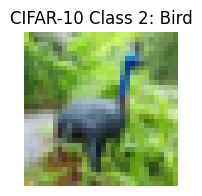

In [12]:
# Load CIFAR-10 and pick first 'bird' image (class 2)
(x_train, y_train), _ = cifar10.load_data()
idx = np.where(y_train.flatten() == 2)[0][0]
img_cifar = img_as_float(x_train[idx])  # shape (32,32,3)
plt.figure(figsize=(2,2))
plt.imshow(img_cifar)
plt.title('CIFAR-10 Class 2: Bird')
plt.axis('off')

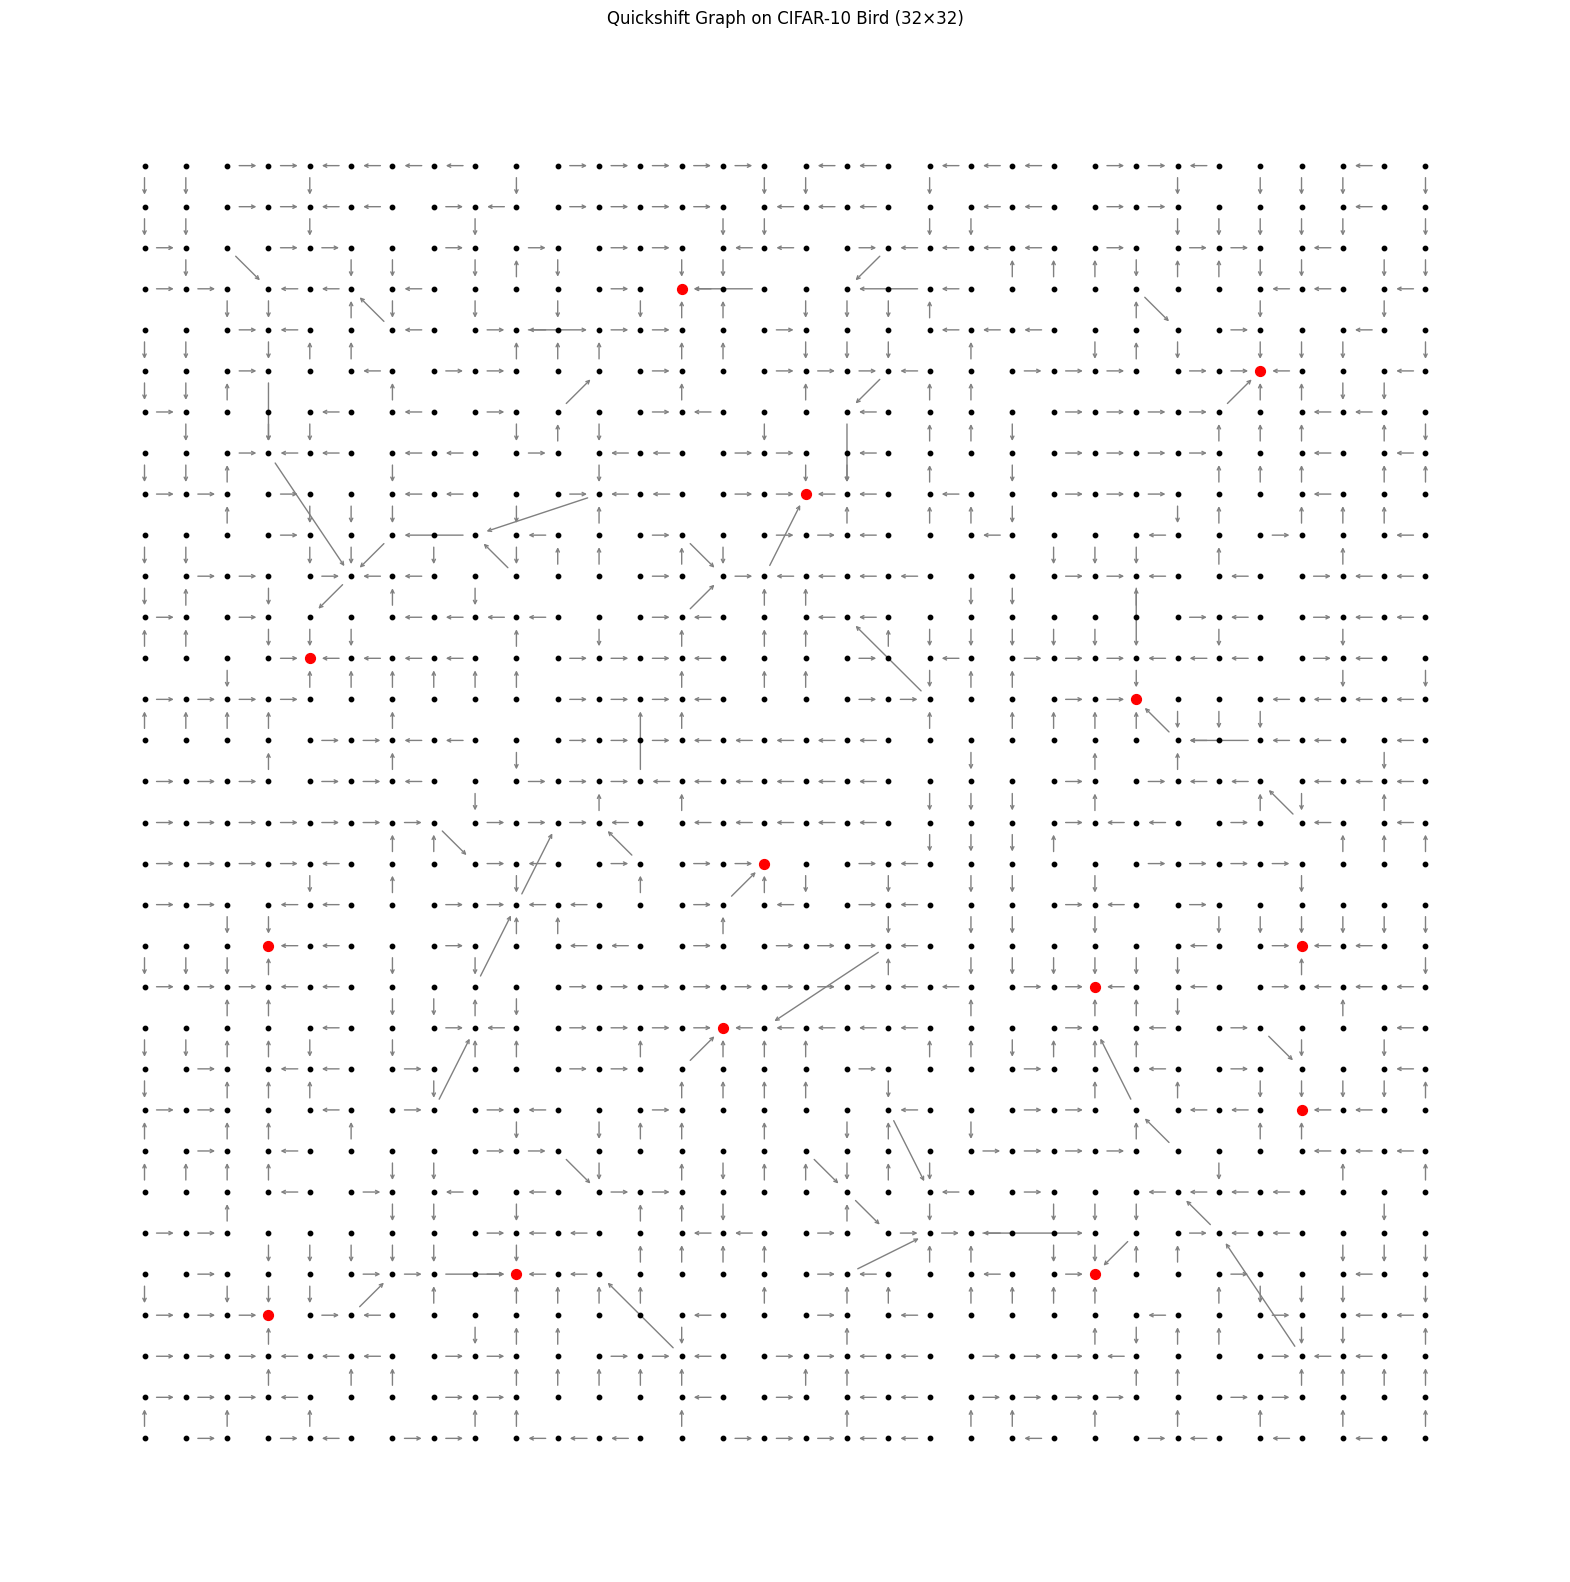

In [13]:
# Build graph
G, P = build_quickshift_graph(img_cifar, kw=3, ks=1, dm=5)
H, W, _ = img_cifar.shape
# Compute positions for plotting
pos = { (i,j):(j, H-1-i) for i in range(H) for j in range(W) }
# Identify sinks (no outgoing edges)
sinks = [n for n in G.nodes if G.out_degree(n)==0]
# Plot
plt.figure(figsize=(20,20))
nx.draw_networkx_nodes(G, pos, node_size=10, node_color='black')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=6, edge_color='gray')
nx.draw_networkx_nodes(G, pos, nodelist=sinks, node_size=50, node_color='red')
plt.axis('off')
plt.title('Quickshift Graph on CIFAR-10 Bird (32×32)')
plt.show()

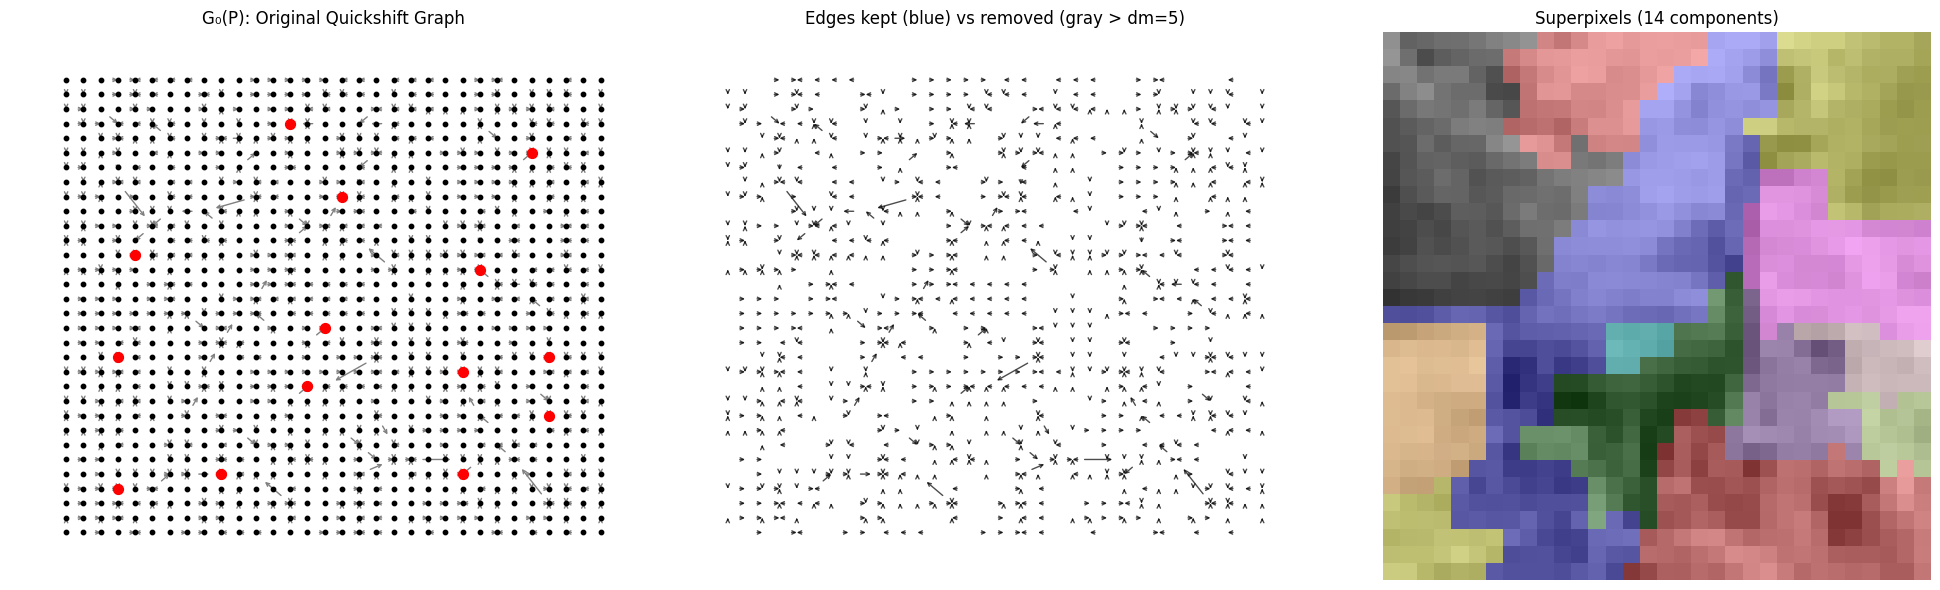

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from skimage.color import label2rgb

G0, P = build_quickshift_graph_with_lengths(img_cifar, kw=3, ks=1)

dm = 5
Gpruned = prune_graph(G0, dm)

label_map, n_components = get_superpixels_from_graph(Gpruned)

H, W, _ = img_cifar.shape
pos = { (i,j):(j, H-1-i) for i in range(H) for j in range(W) }

sinks = [n for n in G0.nodes if G0.out_degree(n)==0]

plt.figure(figsize=(20,6))

# A) Original graph + sinks
plt.subplot(1,3,1)
nx.draw_networkx_nodes(G0, pos, node_size=10, node_color='black')
nx.draw_networkx_edges(G0, pos, arrowstyle='->', arrowsize=6, edge_color='gray')
nx.draw_networkx_nodes(G0, pos, nodelist=sinks, node_size=50, node_color='red')
plt.title('G₀(P): Original Quickshift Graph')
plt.axis('off')


plt.subplot(1,3,2)

removed = set(G0.edges()) - set(Gpruned.edges())
nx.draw_networkx_edges(G0, pos, edgelist=list(removed),
                       arrowstyle='->', arrowsize=6, edge_color='blue', alpha=0.3)

nx.draw_networkx_edges(Gpruned, pos,
                       arrowstyle='->', arrowsize=6, edge_color='black', alpha=0.7)
plt.title(f'Edges kept (black) vs removed (blue > dm={dm})')
plt.axis('off')

plt.subplot(1,3,3)
overlay = label2rgb(label_map, img_cifar, kind='overlay')
plt.imshow(overlay)
plt.title(f'Superpixels ({n_components} components)')
plt.axis('off')

plt.tight_layout()
plt.show()
